In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matchms.importing import load_from_mgf

In [2]:
spectra = [i for i in load_from_mgf("evaluations/sirius_lotus/sirius_orbitrap.mgf")]
qtof_spectra = [i for i in load_from_mgf("evaluations/sirius_lotus/sirius_qtof.mgf")]

spectra.extend(qtof_spectra)

In [3]:
sirius_orbi = pd.read_csv(
    "evaluations/sirius_lotus/sirius_orbitrap/structure_identifications_all.tsv",
    sep="\t",
)

sirius_qtof = pd.read_csv(
    "evaluations/sirius_lotus/sirius_qtof/structure_identifications_all.tsv",
    sep="\t",
)

sirius_results = pd.concat([sirius_orbi, sirius_qtof])

In [4]:
identifiers = set(i.get("identifier") for i in spectra)

In [5]:
result_identifiers = set(sirius_results["mappingFeatureId"].unique())

In [6]:
missing_identifiers = identifiers - result_identifiers

In [7]:
missed_spectra = [i for i in spectra if i.get("identifier") in missing_identifiers]
with_data = [i for i in spectra if i.get("identifier") in result_identifiers]

In [8]:
threshold = 0.01

In [11]:
import numpy as np
from scipy.stats import entropy


def clean_intensities(
    intensities: np.ndarray,
    noise_threshold: float = 0.01,
) -> np.ndarray:
    i = intensities[intensities > noise_threshold * np.max(intensities)]
    sum_intensities = np.sum(i)
    i = i / sum_intensities
    return i


def calculate_spectral_entropy(
    intensities,
    noise_threshold: float = 0.01,
) -> float:
    intensities = clean_intensities(intensities, noise_threshold=noise_threshold)
    return -np.sum(intensities * np.log(intensities))


def calculate_normalized_spectral_entropy(
    intensities,
    noise_threshold: float = 0.01,
) -> float:
    intensities = clean_intensities(intensities, noise_threshold)
    if intensities.shape[0] == 1:
        return calculate_spectral_entropy(intensities)
    return calculate_spectral_entropy(intensities) / np.log(intensities.shape[0])

In [12]:
print(calculate_spectral_entropy(np.array([1, 100, 10])))
print(calculate_normalized_spectral_entropy(np.array([1, 100, 10])))

0.30463609734923813
0.43949698692151334


In [14]:
from matchms import Spectrum
from typing import List


def create_metadata_df(
    spectra: List[Spectrum], has_result: bool, threshold: float = 0.01
) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "identifier": i.get("identifier"),
                f"peaks_below_{threshold}": (i.intensities < threshold).sum(),
                "number_of_peaks": i.mz.shape[0],
                "ratio_of_noise_peaks": (i.intensities < threshold).sum()
                / i.mz.shape[0],
                "prec_parent_diff": i.get("precursor_mz") - float(i.get("parent_mass")),
                "precursor_mz": i.get("precursor_mz"),
                "adduct": i.get("adduct"),
                "collision_energy": i.get("collision_energy"),
                "instrument_type": i.get("instrument_type"),
                "entropy": calculate_spectral_entropy(i.intensities),
                "normalized_entropy": calculate_normalized_spectral_entropy(
                    i.intensities
                ),
                "has_result": has_result,
            }
            for i in spectra
        ]
    )

In [15]:
failed_df = create_metadata_df(missed_spectra, False, threshold=threshold)
with_results = create_metadata_df(with_data, True, threshold=threshold)

In [16]:
df = pd.concat([failed_df, with_results])

In [57]:
df[(df["normalized_entropy"] > 0.999) & (df.has_result == False)]

,identifier,peaks_below_0.01,number_of_peaks,ratio_of_noise_peaks,prec_parent_diff,precursor_mz,adduct,collision_energy,instrument_type,entropy,normalized_entropy,has_result
2791,MassSpecGymID0068993,4,6,0.666667,1.007276,108.080800,[M+H]+,35.0,Orbitrap,0.693067,0.999884,False
2793,MassSpecGymID0068995,4,6,0.666667,1.007276,108.081000,[M+H]+,nan,Orbitrap,0.693073,0.999893,False
5239,MassSpecGymID0088942,0,2,0.000000,1.007276,283.117600,[M+H]+,15.0,Orbitrap,0.692857,0.999581,False
5242,MassSpecGymID0088945,0,2,0.000000,1.007276,283.117600,[M+H]+,15.0,Orbitrap,0.692866,0.999594,False
5590,MassSpecGymID0101456,0,2,0.000000,1.007276,130.032100,[M+H]+,6.5016050000000005,Orbitrap,0.693129,0.999974,False
...,...,...,...,...,...,...,...,...,...,...,...,...
22251,MassSpecGymID0361257,0,2,0.000000,1.007276,315.090000,[M+H]+,nan,Orbitrap,0.693091,0.999919,False
22598,MassSpecGymID0009362,0,2,0.000000,1.007276,154.086949,[M+H]+,10.0,QTOF,0.692864,0.999592,False
23523,MassSpecGymID0052599,0,2,0.000000,1.007276,705.246600,[M+H]+,140.0,QTOF,0.693147,1.000000,False
30254,MassSpecGymID0183371,0,2,0.000000,1.007276,76.038740,[M+H]+,35.0,QTOF,0.693147,1.000000,False


<Axes: xlabel='entropy', ylabel='Density'>

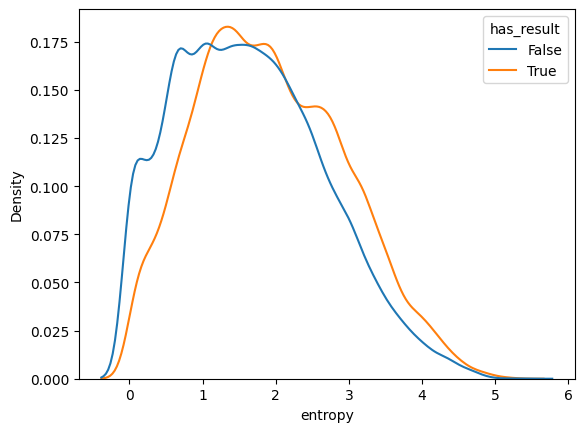

In [ ]:
sns.kdeplot(data=df, x="entropy", hue="has_result")

<Axes: xlabel='entropy', ylabel='number_of_peaks'>

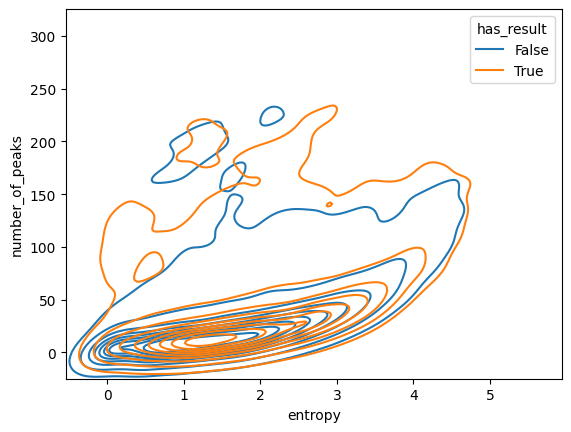

In [ ]:
sns.kdeplot(data=df, x="entropy", y="number_of_peaks", hue="has_result")

In [42]:
msg = pd.read_csv(
    "hf://datasets/roman-bushuiev/MassSpecGym/data/MassSpecGym.tsv", sep="\t"
)

In [60]:
msg[msg.identifier == "MassSpecGymID0183371"]

,identifier,mzs,intensities,smiles,inchikey,formula,precursor_formula,parent_mass,precursor_mz,adduct,instrument_type,collision_energy,fold,simulation_challenge
122814,MassSpecGymID0183371,"42.03247,43.02269","1.0,1.0",CC(=O)NO,RRUDCFGSUDOHDG,C2H5NO2,C2H6NO2,75.031464,76.03874,[M+H]+,QTOF,35.0,train,True


<Axes: ylabel='ratio_of_noise_peaks'>

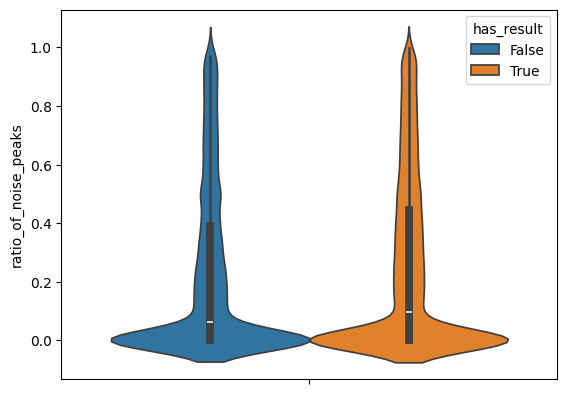

In [20]:
sns.violinplot(data=df, y="ratio_of_noise_peaks", hue="has_result")

<Axes: ylabel='entropy'>

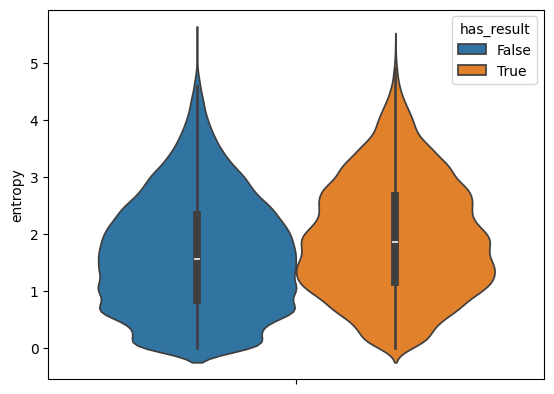

In [21]:
sns.violinplot(data=df, y="entropy", hue="has_result")

<Axes: ylabel='normalized_entropy'>

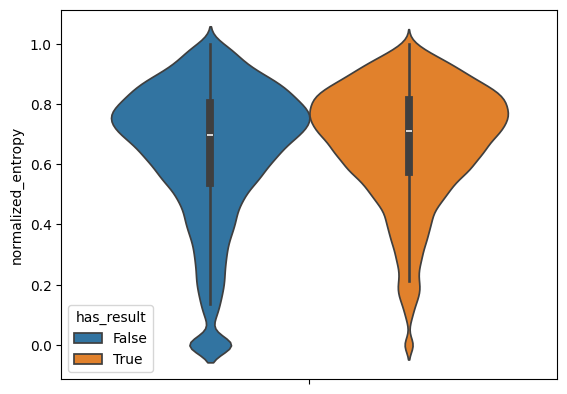

In [22]:
sns.violinplot(data=df, y="normalized_entropy", hue="has_result")

<Axes: ylabel='number_of_peaks'>

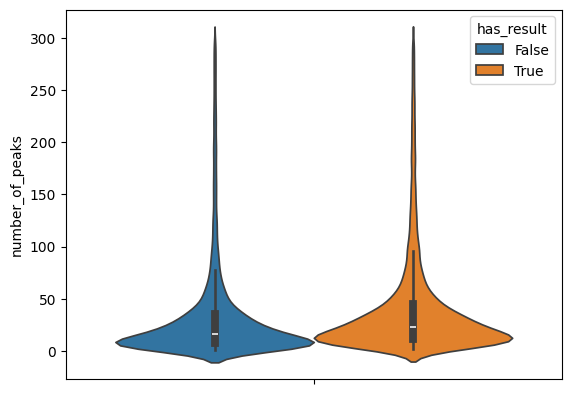

In [23]:
sns.violinplot(data=df, y="number_of_peaks", hue="has_result")

<Axes: ylabel='peaks_below_0.01'>

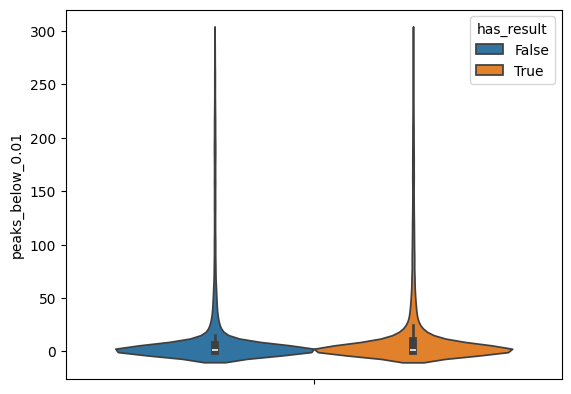

In [24]:
sns.violinplot(data=df, y=f"peaks_below_{threshold}", hue="has_result")

In [34]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df.drop(columns="has_result")
y = df["has_result"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


numeric_features = [
    "number_of_peaks",
    "ratio_of_noise_peaks",
    f"peaks_below_{threshold}",
    "entropy",
    "normalized_entropy",
]
categorical_features = ["instrument_type"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features),
    ]
)

logreg = Pipeline(
    steps=[("preprocess", preprocess), ("model", LogisticRegression(max_iter=1000))]
)

logreg.fit(X_train, y_train)

feature_names = numeric_features + list(
    logreg.named_steps["preprocess"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.58      0.56      0.57      7794
           1       0.57      0.59      0.58      7669

    accuracy                           0.58     15463
   macro avg       0.58      0.58      0.58     15463
weighted avg       0.58      0.58      0.58     15463

ROC AUC: 0.609685514931644


In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            DecisionTreeClassifier(max_depth=3, min_samples_leaf=30, random_state=42),
        ),
    ]
)

dt.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [37]:
y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.59      0.54      0.57      7794
           1       0.57      0.62      0.59      7669

    accuracy                           0.58     15463
   macro avg       0.58      0.58      0.58     15463
weighted avg       0.58      0.58      0.58     15463



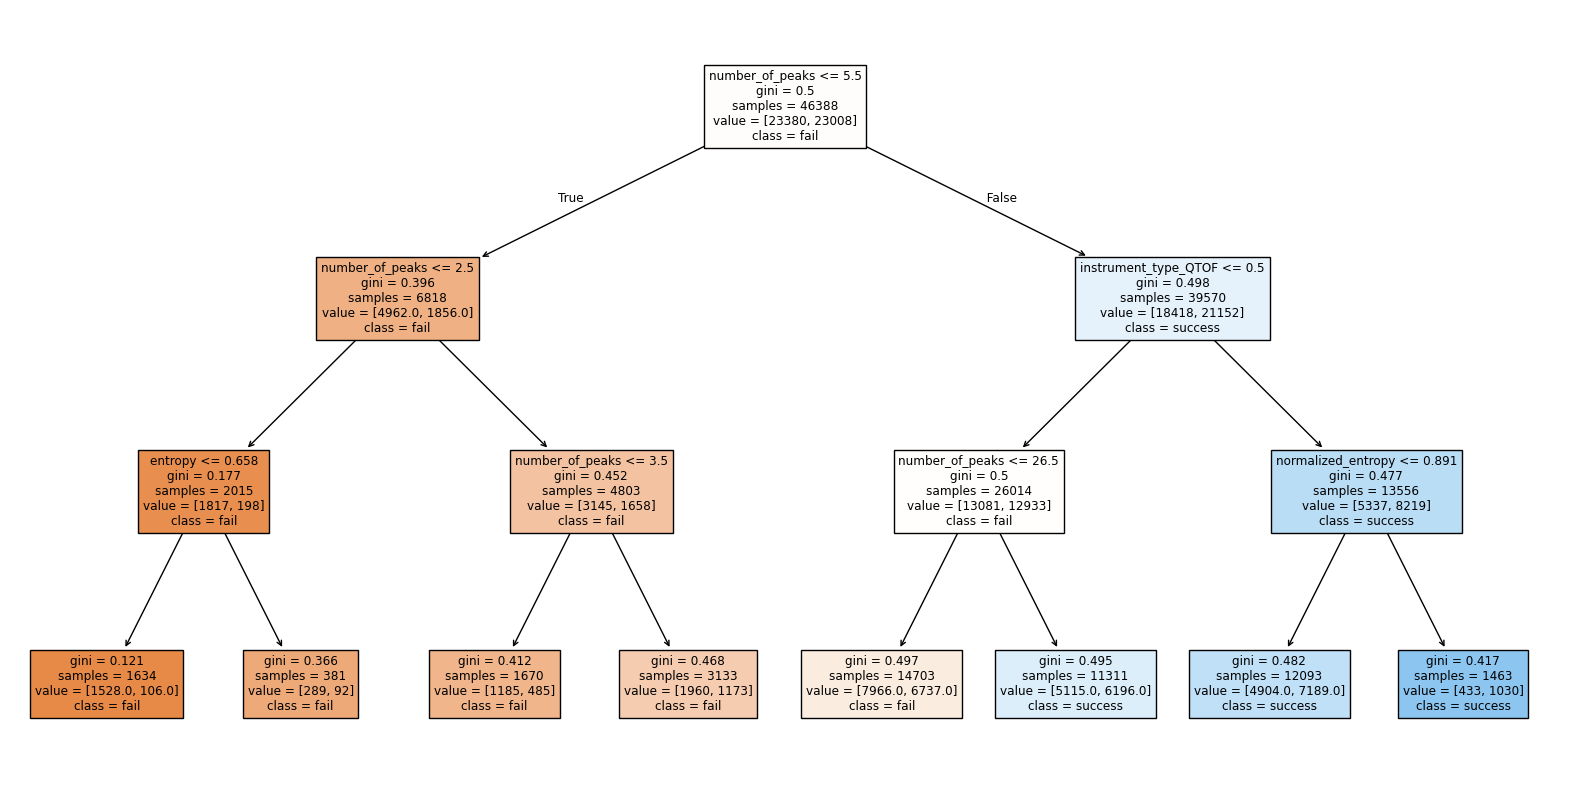

In [38]:
from sklearn import tree

plt.figure(figsize=(20, 10))
tree.plot_tree(
    dt.named_steps["model"],
    feature_names=feature_names,
    class_names=["fail", "success"],
    filled=True,
)
plt.show()

In [30]:
dt.score(X, y)

0.5930381077104655

<Axes: xlabel='number_of_peaks', ylabel='Count'>

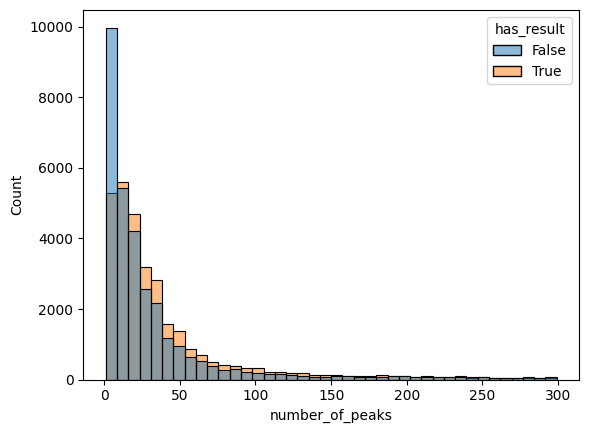

In [31]:
sns.histplot(data=df, x="number_of_peaks", hue="has_result", bins=40, common_norm=False)

<Axes: xlabel='normalized_entropy', ylabel='Count'>

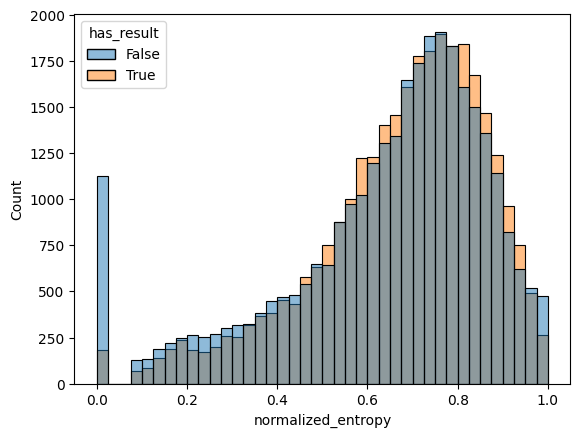

In [ ]:
sns.histplot(
    data=df, x="normalized_entropy", hue="has_result", bins=40, common_norm=False
)